# Friedkin–Johnsen Baseline

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

In [ ]:
ROOT = Path('/home/sammli/llm-network')
CLEAN = ROOT / 'modeling' / 'cleaned_data'
PAIR_DIR = ROOT / 'tests' / 'single_shot_tests' / 'data' / 'stance_converted'
RUN_DIRS = sorted([p for p in CLEAN.glob('run_*') if p.is_dir()])
assert RUN_DIRS, f'No run_* folders in {CLEAN}'

PARAMS = {
    'basis_grid': ['linear', 'linear_abs', 'quadratic', 'quadratic_abs'],
    'ridge_alphas': [0.0, 0.1, 1.0, 10.0],
    'predictor_noise_bins': 6,
    'predictor_rng_seed': 0,
}

print('Pure baseline mode: FJ update uses only lambda, fixed initial opinions, and neighbor opinions on discrete time slices.')


def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def numeric_agent_key(agent_id: str):
    if isinstance(agent_id, str) and agent_id.startswith('agent_'):
        tail = agent_id.split('_')[-1]
        if tail.isdigit():
            return int(tail)
    return 10**9


def parse_agent_id(v):
    if isinstance(v, str) and v.startswith('agent_'):
        return v
    if isinstance(v, int):
        return f'agent_{v}'
    return None


def get_graph_adjacency(graph):
    if isinstance(graph, dict) and 'edges' in graph:
        adj = defaultdict(list)
        for src, dst in graph.get('edges', []):
            s = parse_agent_id(src)
            d = parse_agent_id(dst)
            if s and d:
                adj[s].append(d)
        return dict(adj)
    if isinstance(graph, dict):
        return {k: list(v) for k, v in graph.items() if isinstance(v, list)}
    return {}


def to_unit_interval(x):
    x = np.asarray(x, dtype=float)
    return np.clip((x + 1.0) / 2.0, 0.0, 1.0)


def from_unit_interval(z):
    z = np.asarray(z, dtype=float)
    return np.clip(2.0 * z - 1.0, -1.0, 1.0)


def latest_pair_csv() -> Path:
    candidates = sorted(PAIR_DIR.glob('cleaned_pairs_*.csv'), key=lambda p: p.stat().st_mtime)
    assert candidates, f'No cleaned_pairs_*.csv files found in {PAIR_DIR}'
    return candidates[-1]


def load_first_post_pairs(pair_csv: Path) -> pd.DataFrame:
    pair_df = pd.read_csv(pair_csv)
    for col in ['input_stance_score', 'output_stance_score']:
        pair_df[col] = pd.to_numeric(pair_df[col], errors='coerce')
    pair_df = pair_df.dropna(subset=['input_stance_score', 'output_stance_score']).copy()
    return pair_df


def make_seed_basis(seed_unit: np.ndarray, basis_name: str) -> np.ndarray:
    s = np.asarray(seed_unit, dtype=float).reshape(-1)
    if basis_name == 'linear':
        return np.column_stack([s])
    if basis_name == 'linear_abs':
        return np.column_stack([s, np.abs(s)])
    if basis_name == 'quadratic':
        return np.column_stack([s, s**2])
    if basis_name == 'quadratic_abs':
        return np.column_stack([s, np.abs(s), s**2, np.sign(s - 0.5)])
    raise ValueError(f'Unknown basis: {basis_name}')


def make_regressor(alpha: float):
    if alpha <= 0.0:
        return LinearRegression()
    return Ridge(alpha=alpha)


def fit_noise_profile(seed_unit_train: np.ndarray, residual_train: np.ndarray, n_bins: int = 6, min_sigma: float = 0.03):
    global_sigma = float(np.std(residual_train, ddof=1)) if len(residual_train) > 1 else min_sigma
    global_sigma = max(global_sigma, min_sigma)

    edges = np.quantile(seed_unit_train, np.linspace(0.0, 1.0, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return {'centers': np.array([float(np.mean(seed_unit_train))]), 'sigmas': np.array([global_sigma]), 'min_sigma': min_sigma}

    centers = []
    sigmas = []
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i + 1]
        if i == len(edges) - 2:
            mask = (seed_unit_train >= lo) & (seed_unit_train <= hi)
        else:
            mask = (seed_unit_train >= lo) & (seed_unit_train < hi)
        if mask.sum() == 0:
            continue
        centers.append(float(np.mean(seed_unit_train[mask])))
        sigma = float(np.std(residual_train[mask], ddof=1)) if mask.sum() > 1 else global_sigma
        sigmas.append(max(sigma, min_sigma))

    if not centers:
        centers = [float(np.mean(seed_unit_train))]
        sigmas = [global_sigma]
    return {'centers': np.asarray(centers, dtype=float), 'sigmas': np.asarray(sigmas, dtype=float), 'min_sigma': min_sigma}


def noise_sigma(seed_unit: np.ndarray, noise_profile: dict, noise_scale: float = 1.0) -> np.ndarray:
    seed_unit = np.asarray(seed_unit, dtype=float)
    sigma = np.interp(seed_unit, noise_profile['centers'], noise_profile['sigmas'], left=noise_profile['sigmas'][0], right=noise_profile['sigmas'][-1])
    return np.clip(noise_scale * sigma, float(noise_profile['min_sigma']), None)


def fit_first_post_predictor(pair_df: pd.DataFrame, basis_grid=None, ridge_alphas=None, noise_bins: int = 6):
    basis_grid = basis_grid or PARAMS['basis_grid']
    ridge_alphas = ridge_alphas or PARAMS['ridge_alphas']

    seed_unit = to_unit_interval(pair_df['input_stance_score'].to_numpy(float))
    target_unit = to_unit_interval(pair_df['output_stance_score'].to_numpy(float))
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rows = []

    for basis_name in basis_grid:
        X_all = make_seed_basis(seed_unit, basis_name)
        for alpha in ridge_alphas:
            r2_vals = []
            rmse_vals = []
            for tr, va in kf.split(X_all):
                model = make_regressor(alpha)
                model.fit(X_all[tr], target_unit[tr])
                pred = np.clip(model.predict(X_all[va]), 0.0, 1.0)
                r2_vals.append(r2_score(target_unit[va], pred))
                rmse_vals.append(np.sqrt(np.mean((pred - target_unit[va]) ** 2)))
            rows.append({
                'basis': basis_name,
                'alpha': float(alpha),
                'model_name': 'linear' if alpha <= 0.0 else f'ridge(alpha={alpha:g})',
                'cv_r2_mean': float(np.mean(r2_vals)),
                'cv_r2_std': float(np.std(r2_vals)),
                'cv_rmse_mean': float(np.mean(rmse_vals)),
            })

    leaderboard = pd.DataFrame(rows).sort_values(by=['cv_r2_mean', 'cv_rmse_mean'], ascending=[False, True]).reset_index(drop=True)
    best = leaderboard.iloc[0]
    best_basis = str(best['basis'])
    best_alpha = float(best['alpha'])

    final_model = make_regressor(best_alpha)
    X_all = make_seed_basis(seed_unit, best_basis)
    final_model.fit(X_all, target_unit)
    residual = target_unit - np.clip(final_model.predict(X_all), 0.0, 1.0)
    noise_profile = fit_noise_profile(seed_unit, residual, n_bins=noise_bins, min_sigma=0.03)

    predictor = {
        'basis': best_basis,
        'alpha': best_alpha,
        'model_name': str(best['model_name']),
        'model': final_model,
        'noise_profile': noise_profile,
    }
    return predictor, leaderboard


def sample_first_post_from_seed(seed_ss, predictor, rng=None, sampled: bool = True, noise_scale: float = 1.0):
    scalar_input = np.isscalar(seed_ss)
    seed_arr = np.asarray([seed_ss], dtype=float) if scalar_input else np.asarray(seed_ss, dtype=float)
    seed_unit = to_unit_interval(seed_arr)
    X = make_seed_basis(seed_unit, predictor['basis'])
    mean_unit = np.clip(predictor['model'].predict(X), 0.0, 1.0)
    if sampled:
        if rng is None:
            rng = np.random.default_rng()
        sigma = noise_sigma(seed_unit, predictor['noise_profile'], noise_scale=noise_scale)
        pred_unit = np.clip(mean_unit + rng.normal(0.0, sigma), 0.0, 1.0)
    else:
        pred_unit = mean_unit
    pred_ss = from_unit_interval(pred_unit)
    return float(pred_ss[0]) if scalar_input else pred_ss


PAIR_CSV = latest_pair_csv()
PAIR_DF = load_first_post_pairs(PAIR_CSV)
FIRST_POST_PREDICTOR, PREDICTOR_RES = fit_first_post_predictor(
    PAIR_DF,
    basis_grid=PARAMS['basis_grid'],
    ridge_alphas=PARAMS['ridge_alphas'],
    noise_bins=PARAMS['predictor_noise_bins'],
)
print('Predictor source:', PAIR_CSV.name)
display(PREDICTOR_RES.head(10))


def build_slice_observations(run_dir: Path):
    obs_by_agent_slice = defaultdict(lambda: defaultdict(list))
    first_self_posts = {}
    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return {}, {}, 0

    max_time_slice = 0
    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        agent_id = fp.stem
        for row in load_jsonl(fp):
            slice_idx = row.get('matched_topology_snapshot_time_slice', row.get('message_time_slice'))
            topo = row.get('topology_profile_for_agent', {}) or {}
            obs_ss = topo.get('ss', None)
            if slice_idx is not None and obs_ss is not None:
                slice_idx = int(slice_idx)
                obs_by_agent_slice[agent_id][slice_idx].append(float(obs_ss))
                max_time_slice = max(max_time_slice, slice_idx)

            if row.get('is_self_influence'):
                msg_slice = row.get('message_time_slice', None)
                pub = (row.get('published') or {}).get('stance_score', None)
                msg_index = row.get('message_index', None)
                if msg_slice is None or pub is None or msg_index is None:
                    continue
                candidate = {'time_slice': int(msg_slice), 'stance_score': float(pub), 'message_index': int(msg_index)}
                existing = first_self_posts.get(agent_id)
                if existing is None or (candidate['time_slice'], candidate['message_index']) < (existing['time_slice'], existing['message_index']):
                    first_self_posts[agent_id] = candidate

    obs_by_agent_slice = {
        agent: {ts: float(np.mean(vals)) for ts, vals in ts_map.items()}
        for agent, ts_map in obs_by_agent_slice.items()
    }
    return obs_by_agent_slice, first_self_posts, max_time_slice


def obs_count(run_dir: Path):
    obs_by_agent_slice, _, _ = build_slice_observations(run_dir)
    return sum(len(ts_map) for ts_map in obs_by_agent_slice.values())

RUN_DIR = RUN_DIRS[-1]
print('Using run:', RUN_DIR.name)

def load_run_data(run_dir: Path):
    graph_raw = load_json(run_dir / 'connection_graph.json')
    graph = get_graph_adjacency(graph_raw)
    obs_by_agent_slice, first_self_posts, max_time_slice = build_slice_observations(run_dir)

    agent_ids = set(graph.keys())
    for src, dsts in graph.items():
        agent_ids.add(src)
        agent_ids.update(dsts)
    agent_ids.update(obs_by_agent_slice.keys())
    agent_ids.update(first_self_posts.keys())
    agent_ids = sorted(agent_ids, key=numeric_agent_key)

    return {
        'graph': graph,
        'agent_ids': agent_ids,
        'obs_by_agent_slice': obs_by_agent_slice,
        'first_self_posts': first_self_posts,
        'max_time_slice': int(max_time_slice),
        'pair_csv': str(PAIR_CSV),
    }


def build_predecessors(graph, agent_ids):
    preds = {a: [] for a in agent_ids}
    for src, dsts in graph.items():
        for dst in dsts:
            if dst in preds:
                preds[dst].append(src)
    return preds


def initial_seed_profiles(obs_by_agent_slice, agent_ids):
    seeds = {a: 0.0 for a in agent_ids}
    for a in agent_ids:
        seq = obs_by_agent_slice.get(a, {})
        if 0 in seq:
            seeds[a] = float(seq[0])
        elif seq:
            first_slice = min(seq)
            seeds[a] = float(seq[first_slice])
    return seeds


def evaluate(records):
    if not records:
        return {'mae': np.nan, 'rmse': np.nan, 'r2': np.nan}
    d = np.array([r['pred_ss'] - r['obs_ss'] for r in records], dtype=float)
    obs = np.array([r['obs_ss'] for r in records], dtype=float)
    pred = np.array([r['pred_ss'] for r in records], dtype=float)
    return {
        'mae': float(np.mean(np.abs(d))),
        'rmse': float(np.sqrt(np.mean(d * d))),
        'r2': float(r2_score(obs, pred)),
    }

Pure baseline mode: FJ update uses only lambda, fixed initial opinions, and neighbor opinions on discrete time slices.
Predictor source: cleaned_pairs_20260223-200647.csv


,basis,alpha,model_name,cv_r2_mean,cv_r2_std,cv_rmse_mean
0,quadratic_abs,0.0,linear,0.275692,0.093816,0.079093
1,quadratic,0.0,linear,0.269323,0.092318,0.079510
2,quadratic_abs,0.1,ridge(alpha=0.1),0.266550,0.093671,0.079611
3,quadratic_abs,1.0,ridge(alpha=1),0.256006,0.084087,0.080242
4,quadratic,0.1,ridge(alpha=0.1),0.228176,0.096233,0.081892
5,quadratic_abs,10.0,ridge(alpha=10),0.173018,0.046502,0.084774
6,quadratic,1.0,ridge(alpha=1),0.159144,0.097978,0.085513
7,linear,0.0,linear,0.122729,0.101121,0.087353
8,linear_abs,0.0,linear,0.122729,0.101121,0.087353
9,linear_abs,0.1,ridge(alpha=0.1),0.122722,0.100292,0.087355


Using run: run_20260307-175802


In [3]:
def build_W_for_fj(preds, agent_ids):
    n = len(agent_ids)
    idx = {a: i for i, a in enumerate(agent_ids)}
    W = np.zeros((n, n), dtype=float)
    for dst in agent_ids:
        j = idx[dst]
        p = preds.get(dst, [])
        if p:
            w = 1.0 / len(p)
            for src in p:
                if src in idx:
                    W[j, idx[src]] = w
        else:
            W[j, j] = 1.0
    return W, idx


def initialize_first_slice_states(data, predictor=FIRST_POST_PREDICTOR, rng_seed=0):
    seed_profiles = initial_seed_profiles(data['obs_by_agent_slice'], data['agent_ids'])
    rng = np.random.default_rng(rng_seed)
    rows = []
    z0 = {}

    for agent in data['agent_ids']:
        first_self = data['first_self_posts'].get(agent)
        if first_self is not None and int(first_self['time_slice']) == 0:
            init_ss = float(first_self['stance_score'])
            source = 'observed_first_post'
        else:
            init_ss = float(sample_first_post_from_seed(seed_profiles[agent], predictor=predictor, rng=rng, sampled=True))
            source = 'predicted_from_seed'

        z0[agent] = float(to_unit_interval(init_ss))
        rows.append({
            'agent': agent,
            'seed_profile_ss': float(seed_profiles[agent]),
            'init_post_ss': init_ss,
            'init_post_unit': z0[agent],
            'source': source,
        })

    init_df = pd.DataFrame(rows).sort_values(by='agent', key=lambda s: s.map(numeric_agent_key)).reset_index(drop=True)
    return z0, init_df


def initialize_seed_states(data):
    """Seed-only init: use raw seed profile as z(0) for every agent.

    This matches the "true baseline" interpretation: slice 0 is pre-iteration.
    """
    seed_profiles = initial_seed_profiles(data['obs_by_agent_slice'], data['agent_ids'])
    rows = []
    z0 = {}

    for agent in data['agent_ids']:
        init_ss = float(seed_profiles[agent])
        z0[agent] = float(to_unit_interval(init_ss))
        rows.append({
            'agent': agent,
            'seed_profile_ss': float(seed_profiles[agent]),
            'init_post_ss': init_ss,
            'init_post_unit': z0[agent],
            'source': 'seed_profile',
        })

    init_df = pd.DataFrame(rows).sort_values(by='agent', key=lambda s: s.map(numeric_agent_key)).reset_index(drop=True)
    return z0, init_df


def build_self_post_lookup(run_dir: Path):
    """Map agent -> slice -> stance_score for the LAST self-post in that slice."""
    self_posts = defaultdict(dict)
    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return {}

    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        agent_id = fp.stem
        for row in load_jsonl(fp):
            if not row.get('is_self_influence'):
                continue
            msg_slice = row.get('message_time_slice', None)
            pub = (row.get('published') or {}).get('stance_score', None)
            msg_index = row.get('message_index', None)
            if msg_slice is None or pub is None or msg_index is None:
                continue
            msg_slice = int(msg_slice)
            candidate = {'stance_score': float(pub), 'message_index': int(msg_index)}
            existing = self_posts[agent_id].get(msg_slice)
            if existing is None or candidate['message_index'] > existing['message_index']:
                self_posts[agent_id][msg_slice] = candidate

    return {
        agent: {ts: row['stance_score'] for ts, row in ts_map.items()}
        for agent, ts_map in self_posts.items()
    }


def run_timeslice_fj(data, lam=0.6, predictor=FIRST_POST_PREDICTOR, rng_seed=0):
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    W, idx = build_W_for_fj(preds, agent_ids)
    z0_dict, init_df = initialize_first_slice_states(data, predictor=predictor, rng_seed=rng_seed)

    init_lookup = init_df.set_index('agent')
    init_ss_dict = init_lookup['init_post_ss'].to_dict()
    self_posts_by_agent_slice = build_self_post_lookup(RUN_DIR)

    z0 = np.array([z0_dict[a] for a in agent_ids], dtype=float)
    z = z0.copy()
    effective_obs_unit = {agent: float(z0_dict[agent]) for agent in agent_ids}
    effective_obs_ss = {agent: float(init_ss_dict[agent]) for agent in agent_ids}
    records = []

    for time_slice in range(0, data['max_time_slice'] + 1):
        if time_slice > 0:
            social = W @ z
            z = np.clip(lam * z0 + (1.0 - lam) * social, 0.0, 1.0)

        for agent in agent_ids:
            self_post_map = self_posts_by_agent_slice.get(agent, {})
            if time_slice in self_post_map:
                obs_ss = float(self_post_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
                effective_obs_ss[agent] = obs_ss
                effective_obs_unit[agent] = obs_unit
                obs_source = 'self_post'
            else:
                obs_ss = effective_obs_ss[agent]
                obs_unit = effective_obs_unit[agent]
                obs_source = 'init_or_carry_forward'

            pred_unit = float(z[idx[agent]])
            pred_ss = float(from_unit_interval(pred_unit))
            records.append({
                'time_slice': int(time_slice),
                'agent': agent,
                'pred_unit': pred_unit,
                'obs_unit': obs_unit,
                'pred_ss': pred_ss,
                'obs_ss': obs_ss,
                'obs_source': obs_source,
                'has_self_post': bool(time_slice in self_post_map),
            })

    z_final = {agent: float(z[idx[agent]]) for agent in agent_ids}
    return {'z0': z0_dict, 'z_final': z_final, 'records': records, 'init_df': init_df, 'W': W, 'idx': idx}

In [10]:
# Manual FJ anchor weight (no grid search)
LAMBDA = 0.9
LAMBDA = float(LAMBDA)
assert 0.0 <= LAMBDA <= 1.0

data = load_run_data(RUN_DIR)
print('agents=', len(data['agent_ids']), 'max_time_slice=', data['max_time_slice'])

out = run_timeslice_fj(data, lam=LAMBDA, predictor=FIRST_POST_PREDICTOR, rng_seed=PARAMS['predictor_rng_seed'])
comparison_records = out['records']
m = evaluate(comparison_records)
print(f'FJ (manual lambda={LAMBDA:.3f}) | metrics on stance_score scale:', m)

pd.DataFrame([{'lambda': LAMBDA, 'n_eval': len(comparison_records), **m}])

agents= 30 max_time_slice= 37
FJ (manual lambda=0.900) | metrics on stance_score scale: {'mae': 0.20031621436591668, 'rmse': 0.2588736245504678, 'r2': -12.784738018901008}


,lambda,n_eval,mae,rmse,r2
0,0.9,1140,0.200316,0.258874,-12.784738


Metrics on unit scale [0, 1]: {'mae': 0.10015810718295835, 'rmse': 0.1294368122752339, 'r2': -12.78473801890101}
Using manual lambda = 0.9
First-post predictor = quadratic_abs linear
Comparisons start at time_slice = 0
Scaling: unit = (stance_score + 1) / 2, inverse = 2 * unit - 1
Initialization sources:


,source,count
0,predicted_from_seed,23
1,observed_first_post,7


Slice-0 agreement check: {'max_abs_gap': 0.0, 'mean_abs_gap': 0.0}


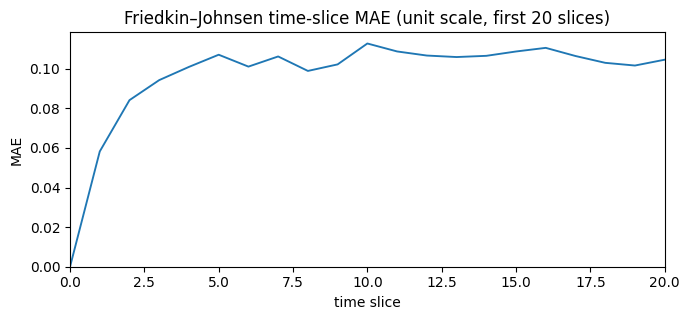

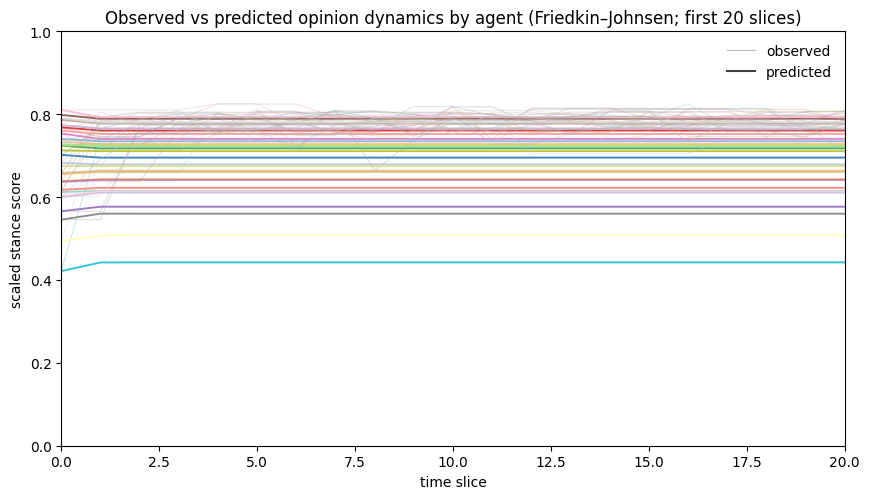

In [11]:
if 'out' not in globals():
    data = load_run_data(RUN_DIR)
    out = run_timeslice_fj(data, lam=float(LAMBDA), predictor=FIRST_POST_PREDICTOR, rng_seed=PARAMS['predictor_rng_seed'])

all_df = pd.DataFrame(out['records']).sort_values(['agent', 'time_slice']).reset_index(drop=True)
df = all_df.copy()
comparison_start = int(df['time_slice'].min()) if not df.empty else 0

df['abs_err'] = (df['pred_unit'] - df['obs_unit']).abs()
met = {
    'mae': float(df['abs_err'].mean()) if not df.empty else np.nan,
    'rmse': float(np.sqrt(np.mean((df['pred_unit'] - df['obs_unit']) ** 2))) if not df.empty else np.nan,
    'r2': float(r2_score(df['obs_unit'], df['pred_unit'])) if len(df) > 1 and df['obs_unit'].nunique() > 1 else np.nan,
}
print('Metrics on unit scale [0, 1]:', met)
print('Using manual lambda =', float(LAMBDA))
print('First-post predictor =', FIRST_POST_PREDICTOR['basis'], FIRST_POST_PREDICTOR['model_name'])
print('Comparisons start at time_slice =', comparison_start)
print('Scaling: unit = (stance_score + 1) / 2, inverse = 2 * unit - 1')

init_df = out['init_df']
print('Initialization sources:')
display(init_df['source'].value_counts().rename_axis('source').reset_index(name='count'))

slice0_df = df[df['time_slice'] == 0].copy()
if not slice0_df.empty:
    slice0_max_gap = float((slice0_df['pred_unit'] - slice0_df['obs_unit']).abs().max())
    slice0_mean_gap = float((slice0_df['pred_unit'] - slice0_df['obs_unit']).abs().mean())
    print('Slice-0 agreement check:', {'max_abs_gap': slice0_max_gap, 'mean_abs_gap': slice0_mean_gap})

MAX_PLOT_SLICE = 20
err_t = df.groupby('time_slice', as_index=False)['abs_err'].mean()
err_t = err_t[err_t['time_slice'] <= MAX_PLOT_SLICE]
plt.figure(figsize=(7.0, 3.3))
plt.plot(err_t['time_slice'], err_t['abs_err'], color='tab:blue', linewidth=1.35)
plt.title(f'Friedkin–Johnsen time-slice MAE (unit scale, first {MAX_PLOT_SLICE} slices)')
plt.xlabel('time slice')
plt.ylabel('MAE')
plt.ylim(0.0, max(0.05, float(err_t['abs_err'].max()) * 1.05))
plt.xlim(0, MAX_PLOT_SLICE)
plt.tight_layout()
plt.show()

from matplotlib.lines import Line2D

agent_order = sorted(df['agent'].unique(), key=numeric_agent_key)
palette = np.array(list(plt.cm.tab20.colors) + list(plt.cm.Set3.colors) + list(plt.cm.Dark2.colors))[:len(agent_order)]

plt.figure(figsize=(8.8, 5.1))
for i, agent in enumerate(agent_order):
    dfa = df[df['agent'] == agent].sort_values('time_slice')
    dfa = dfa[dfa['time_slice'] <= MAX_PLOT_SLICE]
    base_rgb = np.asarray(palette[i][:3], dtype=float)
    obs_rgb = 0.55 * np.array([0.72, 0.72, 0.72]) + 0.45 * base_rgb
    plt.plot(
        dfa['time_slice'],
        dfa['obs_unit'],
        color=(*obs_rgb, 0.35),
        linewidth=0.8,
        solid_capstyle='round',
    )
    plt.plot(
        dfa['time_slice'],
        dfa['pred_unit'],
        color=(*base_rgb, 0.9),
        linewidth=1.35,
        solid_capstyle='round',
    )

legend_handles = [
    Line2D([0], [0], color=(0.45, 0.45, 0.45, 0.45), linewidth=0.9, label='observed'),
    Line2D([0], [0], color=(0.2, 0.2, 0.2, 0.95), linewidth=1.5, label='predicted'),
]
plt.title(f'Observed vs predicted opinion dynamics by agent (Friedkin–Johnsen; first {MAX_PLOT_SLICE} slices)')
plt.xlabel('time slice')
plt.ylabel('scaled stance score')
plt.ylim(0.0, 1.0)
plt.xlim(0, MAX_PLOT_SLICE)
plt.legend(handles=legend_handles, loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

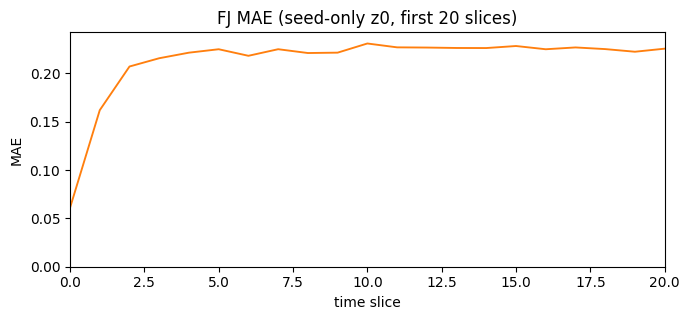

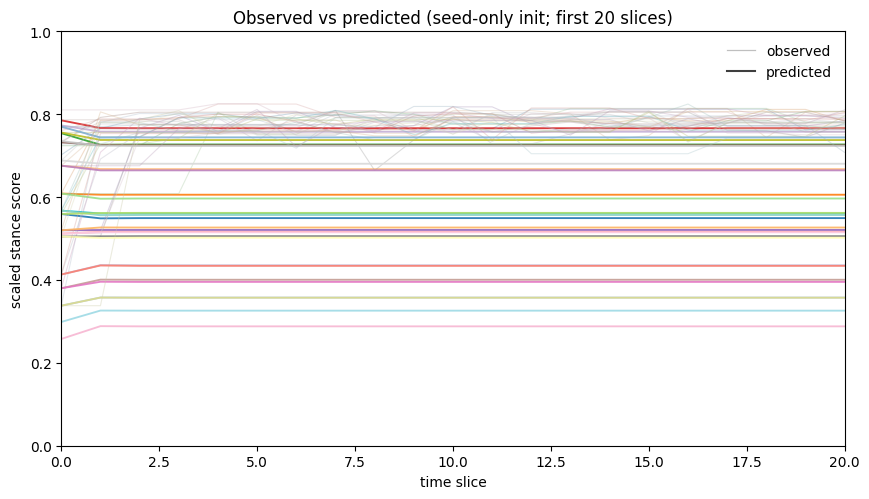

In [12]:
# Init based opinion output
# build direct z0 from seed profiles (unit scale)
seed_profiles = initial_seed_profiles(data['obs_by_agent_slice'], data['agent_ids'])
z0_direct = {a: float(to_unit_interval(seed_profiles[a])) for a in data['agent_ids']}

# helper that mirrors run_timeslice_fj but takes explicit z0_dict

def run_fj_with_fixed_z0(data, z0_dict, lam):
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    W, idx = build_W_for_fj(preds, agent_ids)

    z0 = np.array([z0_dict[a] for a in agent_ids], dtype=float)
    z = z0.copy()
    self_posts_by_agent_slice = build_self_post_lookup(RUN_DIR)

    effective_obs_unit = {agent: float(z0_dict[agent]) for agent in agent_ids}
    # for seed-only we use the raw seed as ss for initial obs
    effective_obs_ss = {agent: float(seed_profiles[agent]) for agent in agent_ids}
    records = []

    for time_slice in range(0, data['max_time_slice'] + 1):
        if time_slice > 0:
            social = W @ z
            z = np.clip(lam * z0 + (1.0 - lam) * social, 0.0, 1.0)

        for agent in agent_ids:
            self_post_map = self_posts_by_agent_slice.get(agent, {})
            if time_slice in self_post_map:
                obs_ss = float(self_post_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
                effective_obs_ss[agent] = obs_ss
                effective_obs_unit[agent] = obs_unit
            else:
                obs_ss = effective_obs_ss[agent]
                obs_unit = effective_obs_unit[agent]

            pred_unit = float(z[idx[agent]])
            pred_ss = float(from_unit_interval(pred_unit))
            records.append({
                'time_slice': int(time_slice),
                'agent': agent,
                'pred_unit': pred_unit,
                'obs_unit': obs_unit,
                'pred_ss': pred_ss,
                'obs_ss': obs_ss,
            })

    return records

# run comparison
lam = float(LAMBDA)
seed_only_records = run_fj_with_fixed_z0(data, z0_direct, lam)

seed_df = pd.DataFrame(seed_only_records).sort_values(['agent','time_slice']).reset_index(drop=True)
seed_df['abs_err'] = (seed_df['pred_unit'] - seed_df['obs_unit']).abs()

MAX_PLOT_SLICE = 20
err_t2 = seed_df.groupby('time_slice', as_index=False)['abs_err'].mean()
err_t2 = err_t2[err_t2['time_slice'] <= MAX_PLOT_SLICE]
plt.figure(figsize=(7.0,3.3))
plt.plot(err_t2['time_slice'], err_t2['abs_err'], color='tab:orange', linewidth=1.35)
plt.title(f'FJ MAE (seed-only z0, first {MAX_PLOT_SLICE} slices)')
plt.xlabel('time slice')
plt.ylabel('MAE')
plt.ylim(0.0, max(0.05, float(err_t2['abs_err'].max())*1.05))
plt.xlim(0,MAX_PLOT_SLICE)
plt.tight_layout()
plt.show()

# trajectory plot
plt.figure(figsize=(8.8,5.1))
for i, agent in enumerate(agent_order):
    dfa = seed_df[seed_df['agent']==agent].sort_values('time_slice')
    dfa = dfa[dfa['time_slice']<=MAX_PLOT_SLICE]
    base_rgb = np.asarray(palette[i][:3], dtype=float)
    obs_rgb = 0.55 * np.array([0.72,0.72,0.72]) + 0.45 * base_rgb
    plt.plot(dfa['time_slice'], dfa['obs_unit'], color=(*obs_rgb,0.35), linewidth=0.8, solid_capstyle='round')
    plt.plot(dfa['time_slice'], dfa['pred_unit'], color=(*base_rgb,0.9), linewidth=1.35, solid_capstyle='round')

plt.title(f'Observed vs predicted (seed-only init; first {MAX_PLOT_SLICE} slices)')
plt.xlabel('time slice')
plt.ylabel('scaled stance score')
plt.ylim(0.0,1.0)
plt.xlim(0,MAX_PLOT_SLICE)
plt.legend(handles=legend_handles, loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

## Rolling / windowed forecast evaluation (avoids steady-state triviality)

### Why the long rollout can be misleading
The Friedkin–Johnsen (FJ) baseline in this notebook iterates a contractive, anchor-to-$z_0$ update and typically converges quickly. As a result, long-horizon rollouts mostly test whether the system is near a fixed point ($z(t+1) \approx z(t)$) rather than whether the *local* slice-to-slice changes are captured.

### Baseline update (unit scale)
Let $z(t) \in [0,1]^n$ and $W$ be row-stochastic neighbor-averaging (predecessor influence). This notebook’s scalar-$\lambda$ FJ update is:

$$
z(t+1) = \lambda z(0) + (1-\lambda) W z(t)
$$

### Rolling evaluation protocol
For each slice $t$, we *restart* the current state to the observed effective opinions $x_{\text{obs}}(t)$, then forecast $x_{\text{obs}}(t+1)$ using the FJ update while keeping the baseline’s fixed anchor $z(0)$:

$$
\hat z(t+1) = \lambda z(0) + (1-\lambda) W x_{\text{obs}}(t)
$$

As in the DeGroot notebook, we report metrics both on:
- **All** effective observations (includes carry-forward)
- **Self-post only** at $t{+}1$ (only score agents who actually post at the next slice)


In [ ]:
WINDOW_HORIZON = 2
WINDOW_HORIZON = int(WINDOW_HORIZON)
assert WINDOW_HORIZON >= 1

START_INDEX = 1
START_INDEX = int(START_INDEX)
assert START_INDEX >= 0

# Manual FJ anchor weight (no grid search)
LAMBDA = 0.9
LAMBDA = float(LAMBDA)
assert 0.0 <= LAMBDA <= 1.0

TARGET_RUN_NAMES = [
    'run_20260306-215035',
    'run_20260307-005112',
]
RUN_DIR_BY_NAME = {p.name: p for p in RUN_DIRS}
TARGET_RUN_DIRS = [RUN_DIR_BY_NAME[name] for name in TARGET_RUN_NAMES]

if START_INDEX == 0:
    print('Open-loop/windowing START_INDEX=0: use pre-post init vector at slice 0 (no slice-0 overwrite)')
else:
    print(f'Open-loop/windowing START_INDEX={START_INDEX}: use END of slice {START_INDEX-1} as given, predict from slice {START_INDEX}')


def _rolling_metrics_unit(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size == 0:
        return {'mae': np.nan, 'rmse': np.nan, 'r2': np.nan}
    err = y_pred - y_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))
    r2 = float(r2_score(y_true, y_pred)) if y_true.size > 1 and np.unique(y_true).size > 1 else np.nan
    return {'mae': mae, 'rmse': rmse, 'r2': r2}


def build_self_post_last_lookup(run_dir: Path):
    """Map agent -> slice -> stance_score for the LAST self-post in that slice."""
    self_posts = defaultdict(dict)
    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return {}

    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        agent_id = fp.stem
        for row in load_jsonl(fp):
            if not row.get('is_self_influence'):
                continue
            msg_slice = row.get('message_time_slice', None)
            pub = (row.get('published') or {}).get('stance_score', None)
            msg_index = row.get('message_index', None)
            if msg_slice is None or pub is None or msg_index is None:
                continue
            msg_slice = int(msg_slice)
            candidate = {'stance_score': float(pub), 'message_index': int(msg_index)}
            existing = self_posts[agent_id].get(msg_slice)
            if existing is None or candidate['message_index'] > existing['message_index']:
                self_posts[agent_id][msg_slice] = candidate

    return {
        agent: {ts: row['stance_score'] for ts, row in ts_map.items()}
        for agent, ts_map in self_posts.items()
    }


def _build_ending_obs_series_unit(run_dir: Path, data: dict, z0_dict: dict, init_ss_dict: dict):
    """Returns:
    - X_end[t] = ending observed opinion vector at slice t (unit scale)
    - has_post[t] = boolean mask for which agents have a self-post at slice t

    Semantics for this section:
    - START_INDEX==0: slice 0 is the init baseline and is not overwritten by slice-0 self-posts.
    - START_INDEX>0: slice 0 is the ENDING state of slice 0 (slice-0 self-posts allowed).
    - "ending" uses the LAST self-post in each slice when present, else carry-forward.
    """
    allow_slice0_self_post = (START_INDEX > 0)

    agent_ids = data['agent_ids']
    self_posts_by_agent_slice = build_self_post_last_lookup(run_dir)

    eff_unit = {agent: float(z0_dict[agent]) for agent in agent_ids}
    eff_ss = {agent: float(init_ss_dict[agent]) for agent in agent_ids}

    X = []
    has_post = []
    for time_slice in range(0, data['max_time_slice'] + 1):
        vec = np.empty(len(agent_ids), dtype=float)
        mask = np.zeros(len(agent_ids), dtype=bool)
        for i, agent in enumerate(agent_ids):
            self_post_map = self_posts_by_agent_slice.get(agent, {})
            if (time_slice > 0 or allow_slice0_self_post) and time_slice in self_post_map:
                obs_ss = float(self_post_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
                eff_ss[agent] = obs_ss
                eff_unit[agent] = obs_unit
                mask[i] = True
            vec[i] = float(eff_unit[agent])
        X.append(vec)
        has_post.append(mask)

    return X, has_post


def _resolve_slice_range(data: dict, steps: int):
    max_slice = int(data['max_time_slice'])
    start_index = int(START_INDEX)
    if start_index > max_slice:
        raise ValueError(f'START_INDEX={start_index} out of range for run (max_time_slice={max_slice}).')

    given_slice = 0 if start_index == 0 else (start_index - 1)
    pred_start = given_slice + 1
    pred_end = min(max_slice, pred_start + int(steps) - 1)
    horizon = max(0, pred_end - pred_start + 1)
    return given_slice, pred_start, pred_end, horizon


def rollout_eval_fj_from_init(
    run_dir: Path,
    lam: float,
    *,
    steps: int,
    self_post_only: bool = True,
 ) -> dict:
    """Open-loop rollout.

    Important: In FJ, the anchor z(0) is always the seed baseline.
    START_INDEX only changes the starting state we roll forward from.

    If START_INDEX==0: start from pre-post init vector at slice 0, then predict slice 1..horizon.
    If START_INDEX>0: start from ENDING state of slice START_INDEX-1, then predict from slice START_INDEX.
    """
    data = load_run_data(run_dir)
    agent_ids = data['agent_ids']

    preds = build_predecessors(data['graph'], agent_ids)
    W, _ = build_W_for_fj(preds, agent_ids)

    z0_dict, init_df = initialize_seed_states(data)
    init_ss_dict = init_df.set_index('agent')['init_post_ss'].to_dict()
    X, has_post = _build_ending_obs_series_unit(run_dir, data, z0_dict, init_ss_dict)

    given_slice, pred_start, pred_end, horizon = _resolve_slice_range(data, steps=int(steps))
    if horizon <= 0:
        return {'n_eval': 0, 'n_scored_slices': 0, 'horizon': int(horizon), **_rolling_metrics_unit([], [])}

    z_anchor = np.array([float(z0_dict[a]) for a in agent_ids], dtype=float)
    z = z_anchor.copy() if START_INDEX == 0 else np.array(X[given_slice], dtype=float)

    y_true_all = []
    y_pred_all = []
    n_scored_slices = 0

    lam = float(lam)

    for t in range(pred_start, pred_end + 1):
        social = W @ z
        z = np.clip(lam * z_anchor + (1.0 - lam) * social, 0.0, 1.0)

        y_true = np.array(X[t], dtype=float)
        mask = has_post[t] if self_post_only else np.ones_like(has_post[t], dtype=bool)
        if not bool(mask.any()):
            continue
        y_true_all.append(y_true[mask])
        y_pred_all.append(z[mask])
        n_scored_slices += 1

    if not y_true_all:
        return {'n_eval': 0, 'n_scored_slices': int(n_scored_slices), 'horizon': int(horizon), **_rolling_metrics_unit([], [])}

    yt = np.concatenate(y_true_all)
    yp = np.concatenate(y_pred_all)
    return {
        'n_eval': int(yt.size),
        'n_scored_slices': int(n_scored_slices),
        'horizon': int(horizon),
        **_rolling_metrics_unit(yt, yp),
    }


def rollout_eval_constant_init(
    run_dir: Path,
    *,
    steps: int,
    self_post_only: bool = True,
 ) -> dict:
    """Trivial baseline: predict x(t) = x(given_slice) for all scored t."""
    data = load_run_data(run_dir)
    agent_ids = data['agent_ids']

    z0_dict, init_df = initialize_seed_states(data)
    init_ss_dict = init_df.set_index('agent')['init_post_ss'].to_dict()
    X, has_post = _build_ending_obs_series_unit(run_dir, data, z0_dict, init_ss_dict)

    given_slice, pred_start, pred_end, horizon = _resolve_slice_range(data, steps=int(steps))
    if horizon <= 0:
        return {'n_eval': 0, 'n_scored_slices': 0, 'horizon': int(horizon), **_rolling_metrics_unit([], [])}

    z_init = np.array([float(z0_dict[a]) for a in agent_ids], dtype=float) if START_INDEX == 0 else np.array(X[given_slice], dtype=float)

    y_true_all = []
    y_pred_all = []
    n_scored_slices = 0

    for t in range(pred_start, pred_end + 1):
        y_true = np.array(X[t], dtype=float)
        mask = has_post[t] if self_post_only else np.ones_like(has_post[t], dtype=bool)
        if not bool(mask.any()):
            continue
        y_true_all.append(y_true[mask])
        y_pred_all.append(z_init[mask])
        n_scored_slices += 1

    if not y_true_all:
        return {'n_eval': 0, 'n_scored_slices': int(n_scored_slices), 'horizon': int(horizon), **_rolling_metrics_unit([], [])}

    yt = np.concatenate(y_true_all)
    yp = np.concatenate(y_pred_all)
    return {
        'n_eval': int(yt.size),
        'n_scored_slices': int(n_scored_slices),
        'horizon': int(horizon),
        **_rolling_metrics_unit(yt, yp),
    }


rows = []
for run_dir in TARGET_RUN_DIRS:
    for self_post_only in [True, False]:
        out = rollout_eval_fj_from_init(
            run_dir,
            lam=float(LAMBDA),
            steps=WINDOW_HORIZON,
            self_post_only=self_post_only,
        )
        base = rollout_eval_constant_init(
            run_dir,
            steps=WINDOW_HORIZON,
            self_post_only=self_post_only,
        )
        rows.append({
            'run': run_dir.name,
            'model': 'fj_open_loop',
            'lambda': float(LAMBDA),
            'subset': ('self_post_only' if self_post_only else 'all_effective'),
            **out,
            'baseline_mae': base['mae'],
            'baseline_rmse': base['rmse'],
            'baseline_r2': base['r2'],
        })

roll_df = pd.DataFrame(rows)
roll_df = roll_df.sort_values(['run', 'subset', 'rmse'], ascending=[True, True, True]).reset_index(drop=True)
print(f'Open-loop rollout evaluation (lambda={LAMBDA:.3f}; WINDOW_HORIZON={WINDOW_HORIZON}; START_INDEX={START_INDEX}; unit scale).')
display(roll_df)

Open-loop/windowing START_INDEX=1: use END of slice 0 as given, predict from slice 1
Open-loop rollout evaluation (lambda=0.600; WINDOW_HORIZON=2; START_INDEX=1; unit scale).


,run,model,lambda,subset,n_eval,n_scored_slices,horizon,mae,rmse,r2,baseline_mae,baseline_rmse,baseline_r2
0,run_20260306-215035,fj_open_loop,0.6,all_effective,60,2,2,0.081335,0.106569,0.581386,0.027988,0.078594,0.772317
1,run_20260306-215035,fj_open_loop,0.6,self_post_only,9,2,2,0.153364,0.172879,-13.286489,0.137838,0.177451,-14.052257
2,run_20260307-005112,fj_open_loop,0.6,all_effective,60,2,2,0.064197,0.086691,0.697051,0.014385,0.054883,0.878579
3,run_20260307-005112,fj_open_loop,0.6,self_post_only,6,2,2,0.104308,0.143100,-1.054180,0.102639,0.155542,-1.426912


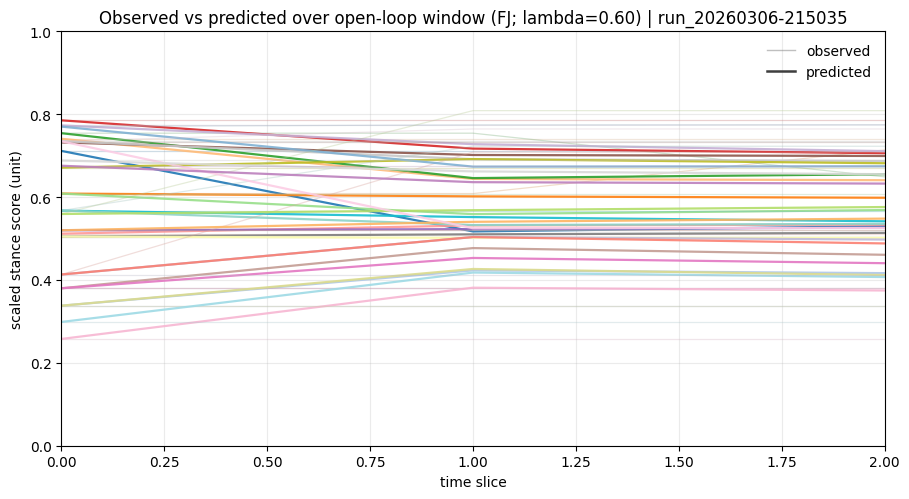

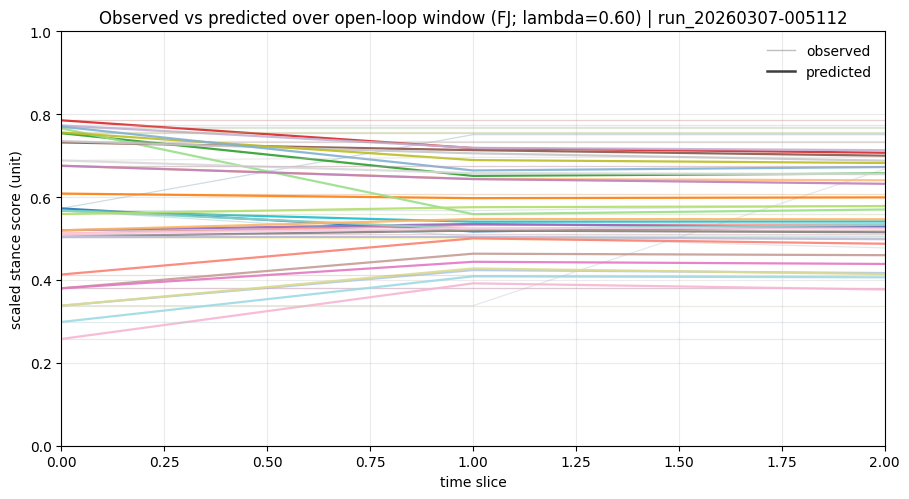

In [8]:
# Open-loop plots: show trajectories over the predicted window
assert 'TARGET_RUN_DIRS' in globals() and len(TARGET_RUN_DIRS) > 0
assert 'WINDOW_HORIZON' in globals()
assert 'START_INDEX' in globals() and int(START_INDEX) >= 0
assert 'LAMBDA' in globals()


def build_self_post_last_lookup(run_dir: Path):
    """Map agent -> slice -> stance_score for the LAST self-post in that slice."""
    self_posts = defaultdict(dict)
    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return {}

    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        agent_id = fp.stem
        for row in load_jsonl(fp):
            if not row.get('is_self_influence'):
                continue
            msg_slice = row.get('message_time_slice', None)
            pub = (row.get('published') or {}).get('stance_score', None)
            msg_index = row.get('message_index', None)
            if msg_slice is None or pub is None or msg_index is None:
                continue
            msg_slice = int(msg_slice)
            candidate = {'stance_score': float(pub), 'message_index': int(msg_index)}
            existing = self_posts[agent_id].get(msg_slice)
            if existing is None or candidate['message_index'] > existing['message_index']:
                self_posts[agent_id][msg_slice] = candidate

    return {
        agent: {ts: row['stance_score'] for ts, row in ts_map.items()}
        for agent, ts_map in self_posts.items()
    }


def _build_ending_obs_series_unit_for_plot(run_dir: Path, data: dict, z0_dict: dict, init_ss_dict: dict):
    allow_slice0_self_post = (int(START_INDEX) > 0)

    agent_ids = data['agent_ids']
    self_posts_by_agent_slice = build_self_post_last_lookup(run_dir)

    eff_unit = {agent: float(z0_dict[agent]) for agent in agent_ids}
    eff_ss = {agent: float(init_ss_dict[agent]) for agent in agent_ids}

    X = []
    for time_slice in range(0, data['max_time_slice'] + 1):
        vec = np.empty(len(agent_ids), dtype=float)
        for i, agent in enumerate(agent_ids):
            self_post_map = self_posts_by_agent_slice.get(agent, {})
            if (time_slice > 0 or allow_slice0_self_post) and time_slice in self_post_map:
                obs_ss = float(self_post_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
                eff_ss[agent] = obs_ss
                eff_unit[agent] = obs_unit
            vec[i] = float(eff_unit[agent])
        X.append(vec)
    return X


def _resolve_slice_range(data: dict, steps: int):
    max_slice = int(data['max_time_slice'])
    start_index = int(START_INDEX)
    if start_index > max_slice:
        raise ValueError(f'START_INDEX={start_index} out of range for run (max_time_slice={max_slice}).')

    given_slice = 0 if start_index == 0 else (start_index - 1)
    pred_start = given_slice + 1
    pred_end = min(max_slice, pred_start + int(steps) - 1)
    horizon = max(0, pred_end - pred_start + 1)
    return given_slice, pred_start, pred_end, horizon


from matplotlib.lines import Line2D

for run_dir in TARGET_RUN_DIRS:
    data = load_run_data(run_dir)
    agent_ids = data['agent_ids']

    preds = build_predecessors(data['graph'], agent_ids)
    W, _ = build_W_for_fj(preds, agent_ids)

    z0_dict, init_df = initialize_seed_states(data)
    init_ss_dict = init_df.set_index('agent')['init_post_ss'].to_dict()
    X_end = _build_ending_obs_series_unit_for_plot(run_dir, data, z0_dict, init_ss_dict)

    given_slice, pred_start, pred_end, horizon = _resolve_slice_range(data, steps=int(WINDOW_HORIZON))
    if horizon <= 0:
        print(f'{run_dir.name}: horizon=0 (nothing to plot)')
        continue

    z_anchor = np.array([float(z0_dict[a]) for a in agent_ids], dtype=float)
    lam = float(LAMBDA)

    t_axis = np.arange(given_slice, pred_end + 1)
    obs_mat = np.stack([np.array(X_end[t], dtype=float) for t in t_axis], axis=0)
    pred_mat = np.empty_like(obs_mat)
    pred_mat[0] = obs_mat[0].copy()

    z = z_anchor.copy() if int(START_INDEX) == 0 else pred_mat[0].copy()
    for i, t in enumerate(range(pred_start, pred_end + 1), start=1):
        social = W @ z
        z = np.clip(lam * z_anchor + (1.0 - lam) * social, 0.0, 1.0)
        pred_mat[i] = z.copy()

    agent_order = sorted(agent_ids, key=numeric_agent_key)
    palette = np.array(list(plt.cm.tab20.colors) + list(plt.cm.Set3.colors) + list(plt.cm.Dark2.colors))[:len(agent_order)]
    idx_map = {a: k for k, a in enumerate(agent_ids)}

    plt.figure(figsize=(9.2, 5.1))
    for i, agent in enumerate(agent_order):
        j = idx_map[agent]
        base_rgb = np.asarray(palette[i][:3], dtype=float)
        obs_rgb = 0.55 * np.array([0.72, 0.72, 0.72]) + 0.45 * base_rgb
        plt.plot(t_axis, obs_mat[:, j], color=(*obs_rgb, 0.35), linewidth=0.9, solid_capstyle='round')
        plt.plot(t_axis, pred_mat[:, j], color=(*base_rgb, 0.9), linewidth=1.6, solid_capstyle='round')

    legend_handles = [
        Line2D([0], [0], color=(0.45, 0.45, 0.45, 0.45), linewidth=1.0, label='observed'),
        Line2D([0], [0], color=(0.2, 0.2, 0.2, 0.95), linewidth=1.8, label='predicted'),
    ]
    plt.title(f'Observed vs predicted over open-loop window (FJ; lambda={lam:.2f}) | {run_dir.name}')
    plt.xlabel('time slice')
    plt.ylabel('scaled stance score (unit)')
    plt.ylim(0, 1)
    plt.xlim(int(t_axis.min()), int(t_axis.max()))
    plt.legend(handles=legend_handles, loc='upper right', frameon=False)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

Rolling-window prediction | run_20260306-215035 | lambda=0.600 | window=2 | slices 0..20


,time_slice,mae_unit
0,0,0.000000
1,1,0.081698
2,2,0.080972
3,3,0.090353
4,4,0.113563
5,5,0.104076
6,6,0.122119
7,7,0.121983
8,8,0.148560
9,9,0.127422


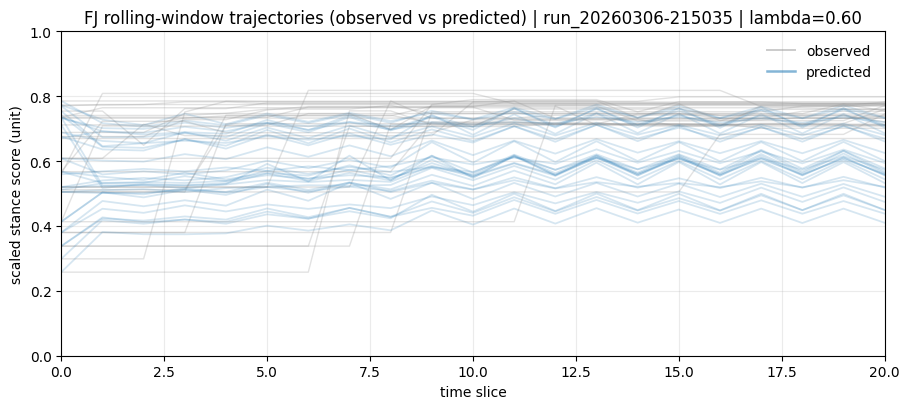

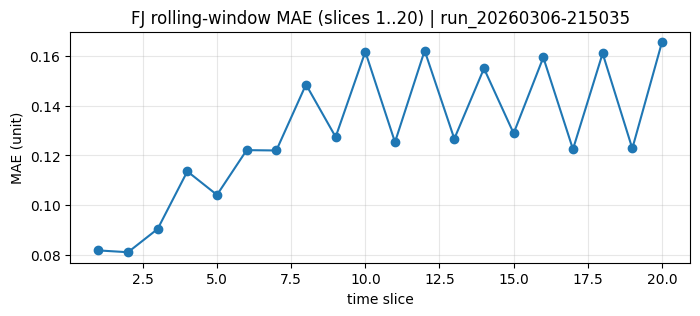

Rolling-window prediction | run_20260307-005112 | lambda=0.600 | window=2 | slices 0..20


,time_slice,mae_unit
0,0,0.000000
1,1,0.061550
2,2,0.066844
3,3,0.081119
4,4,0.100370
5,5,0.096428
6,6,0.110826
7,7,0.106198
8,8,0.109025
9,9,0.116072


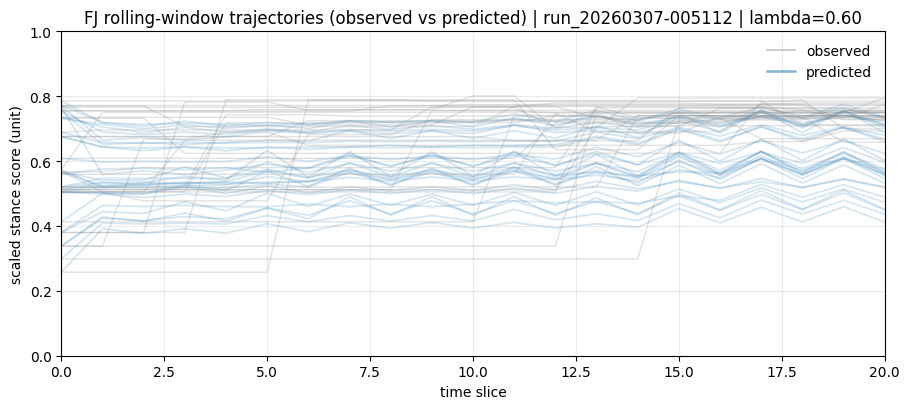

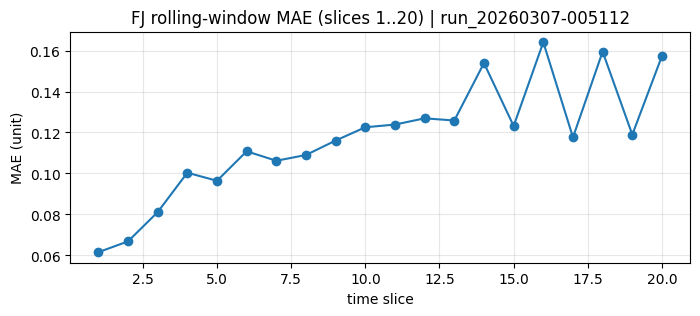

In [9]:
# Rolling window prediction: predict slices 1..20 starting from given slice 0
assert 'TARGET_RUN_DIRS' in globals() and len(TARGET_RUN_DIRS) > 0
assert 'WINDOW_HORIZON' in globals() and int(WINDOW_HORIZON) >= 1
assert 'LAMBDA' in globals()
assert 0.0 <= float(LAMBDA) <= 1.0

PREDICT_MAX_SLICE = 20
PREDICT_WINDOW = int(WINDOW_HORIZON)  # default 2


def build_self_post_last_lookup(run_dir: Path):
    """Map agent -> slice -> stance_score for the LAST self-post in that slice."""
    self_posts = defaultdict(dict)
    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return {}

    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        agent_id = fp.stem
        for row in load_jsonl(fp):
            if not row.get('is_self_influence'):
                continue
            msg_slice = row.get('message_time_slice', None)
            pub = (row.get('published') or {}).get('stance_score', None)
            msg_index = row.get('message_index', None)
            if msg_slice is None or pub is None or msg_index is None:
                continue
            msg_slice = int(msg_slice)
            candidate = {'stance_score': float(pub), 'message_index': int(msg_index)}
            existing = self_posts[agent_id].get(msg_slice)
            if existing is None or candidate['message_index'] > existing['message_index']:
                self_posts[agent_id][msg_slice] = candidate

    return {
        agent: {ts: row['stance_score'] for ts, row in ts_map.items()}
        for agent, ts_map in self_posts.items()
    }


def _ending_obs_series_unit_allow_slice0(run_dir: Path, data: dict, z0_dict: dict, init_ss_dict: dict):
    """Ending observed series where slice-0 self-posts are allowed (START_INDEX=1 semantics)."""
    agent_ids = data['agent_ids']
    self_posts_by_agent_slice = build_self_post_last_lookup(run_dir)

    eff_unit = {agent: float(z0_dict[agent]) for agent in agent_ids}
    eff_ss = {agent: float(init_ss_dict[agent]) for agent in agent_ids}

    X = []
    for time_slice in range(0, data['max_time_slice'] + 1):
        vec = np.empty(len(agent_ids), dtype=float)
        for i, agent in enumerate(agent_ids):
            self_post_map = self_posts_by_agent_slice.get(agent, {})
            if time_slice in self_post_map:
                obs_ss = float(self_post_map[time_slice])
                obs_unit = float(to_unit_interval(obs_ss))
                eff_ss[agent] = obs_ss
                eff_unit[agent] = obs_unit
            vec[i] = float(eff_unit[agent])
        X.append(vec)
    return X


def rolling_window_forecast_fj(run_dir: Path, lam: float, *, window: int, max_slice: int = 20):
    data = load_run_data(run_dir)
    agent_ids = data['agent_ids']

    preds = build_predecessors(data['graph'], agent_ids)
    W, _ = build_W_for_fj(preds, agent_ids)

    z0_dict, init_df = initialize_seed_states(data)
    init_ss_dict = init_df.set_index('agent')['init_post_ss'].to_dict()
    X_end = _ending_obs_series_unit_allow_slice0(run_dir, data, z0_dict, init_ss_dict)

    z_anchor = np.array([float(z0_dict[a]) for a in agent_ids], dtype=float)
    lam = float(lam)

    max_slice = min(int(max_slice), int(data['max_time_slice']))
    obs = [np.array(X_end[t], dtype=float) for t in range(0, max_slice + 1)]
    pred = [None] * (max_slice + 1)

    pred[0] = obs[0].copy()
    s0 = 0
    window = int(window)
    while s0 < max_slice:
        z = obs[s0].copy()
        steps = min(window, max_slice - s0)
        for k in range(1, steps + 1):
            social = W @ z
            z = np.clip(lam * z_anchor + (1.0 - lam) * social, 0.0, 1.0)
            pred[s0 + k] = z.copy()
        s0 += window

    pred_mat = np.stack(pred, axis=0)
    obs_mat = np.stack(obs, axis=0)
    t_axis = np.arange(0, max_slice + 1)
    return agent_ids, t_axis, pred_mat, obs_mat


from matplotlib.lines import Line2D

for run_dir in TARGET_RUN_DIRS:
    lam_star = float(LAMBDA)
    agent_ids, t_axis, pred_mat, obs_mat = rolling_window_forecast_fj(
        run_dir, lam=lam_star, window=PREDICT_WINDOW, max_slice=PREDICT_MAX_SLICE
    )

    mae_by_slice = np.mean(np.abs(pred_mat - obs_mat), axis=1)
    out_df = pd.DataFrame({'time_slice': t_axis, 'mae_unit': mae_by_slice})

    print(
        f'Rolling-window prediction | {run_dir.name} | lambda={lam_star:.3f} | window={PREDICT_WINDOW} | slices 0..{int(t_axis[-1])}'
    )
    display(out_df.head(25))

    # Predicted vs observed trajectories (slices 0..20)
    plt.figure(figsize=(9.2, 4.2))
    for j in range(obs_mat.shape[1]):
        plt.plot(t_axis, obs_mat[:, j], color=(0.55, 0.55, 0.55, 0.25), linewidth=1.0)
        plt.plot(t_axis, pred_mat[:, j], color=(0.12, 0.47, 0.71, 0.18), linewidth=1.3)

    legend_handles = [
        Line2D([0], [0], color=(0.55, 0.55, 0.55, 0.45), linewidth=1.4, label='observed'),
        Line2D([0], [0], color=(0.12, 0.47, 0.71, 0.55), linewidth=1.8, label='predicted'),
    ]
    plt.title(f'FJ rolling-window trajectories (observed vs predicted) | {run_dir.name} | lambda={lam_star:.2f}')
    plt.xlabel('time slice')
    plt.ylabel('scaled stance score (unit)')
    plt.ylim(0.0, 1.0)
    plt.xlim(int(t_axis.min()), int(t_axis.max()))
    plt.legend(handles=legend_handles, loc='upper right', frameon=False)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Per-slice MAE curve
    plt.figure(figsize=(8, 3))
    plt.plot(out_df['time_slice'][1:], out_df['mae_unit'][1:], marker='o')
    plt.title(f'FJ rolling-window MAE (slices 1..{int(t_axis[-1])}) | {run_dir.name}')
    plt.xlabel('time slice')
    plt.ylabel('MAE (unit)')
    plt.grid(True, alpha=0.3)
    plt.show()